<a href="https://colab.research.google.com/github/Rohan-1103/Data-Science/blob/main/DL/Exponentially_Weighted_Moving_Average.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
data = pd.read_csv("DailyDelhiClimate.csv")
data

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1571,2017-04-20,34.500000,27.500000,5.562500,998.625000
1572,2017-04-21,34.250000,39.375000,6.962500,999.875000
1573,2017-04-22,32.900000,40.900000,8.890000,1001.600000
1574,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [43]:
data = data[['date', 'meantemp']]
data = data.iloc[:750]

In [48]:
x2 = data['meantemp'].ewm(alpha=0.9).mean()
data['ewma_alpha_0_9'] = x2
display(data.head())

,date,meantemp,ewma,ewma_alpha_0_9
0,2013-01-01,10.000000,10.000000,10.000000
1,2013-01-02,7.400000,8.631579,7.636364
2,2013-01-03,7.166667,8.091021,7.213213
3,2013-01-04,8.666667,8.258408,8.521452
4,2013-01-05,6.000000,7.706918,6.252123


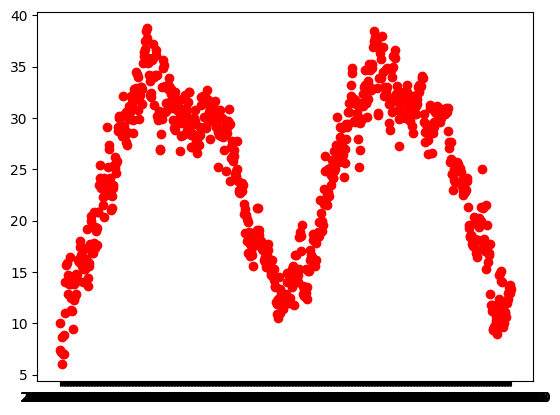

In [44]:
plt.scatter(data['date'], data['meantemp'], c='red')

In [45]:
x1 = data['meantemp'].ewm(alpha=0.1).mean()

In [46]:
data['ewma'] = x1
data

,date,meantemp,ewma
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,8.631579
2,2013-01-03,7.166667,8.091021
3,2013-01-04,8.666667,8.258408
4,2013-01-05,6.000000,7.706918
...,...,...,...
745,2015-01-16,13.000000,12.087905
746,2015-01-17,13.500000,12.229115
747,2015-01-18,13.000000,12.306203
748,2015-01-19,13.750000,12.450583


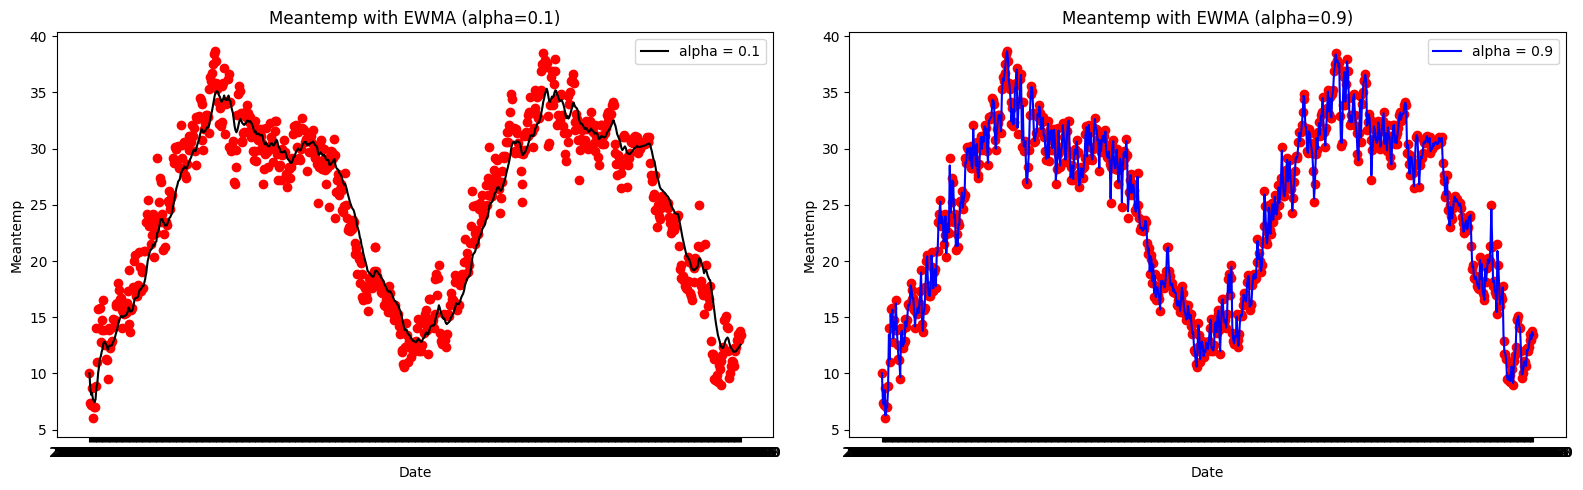

In [51]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(data['date'], data['meantemp'], c='red')
plt.plot(data['date'], x1, color = 'black', label = 'alpha = 0.1')
plt.title('Meantemp with EWMA (alpha=0.1)')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(data['date'], data['meantemp'], c='red')
plt.plot(data['date'], x2, color = 'blue', label = 'alpha = 0.9')
plt.title('Meantemp with EWMA (alpha=0.9)')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.legend()

plt.tight_layout()
plt.show()